# 6.0 KeyRank — 128비트 키 전체의 순위

## 이 노트북이 답하는 질문

공격이 키 16바이트를 **전부 1등으로** 맞히지는 못했다고 하자. 그래도 각 바이트에서
정답이 상위권이라면, 남은 후보를 **전수조사**할 수 있을지 모른다.

**그 남은 일이 얼마나 되는가?** 즉 정답 키가 전체 $2^{128}$ 후보 중 몇 번째인가?

바이트별 순위를 곱하면 될 것 같지만 그렇지 않다. 전체 순위는 "각 바이트 점수의 합이
정답보다 좋은 조합이 몇 개인가" 이고, 이는 단순 곱셈으로 나오지 않는다.
`scalib.postprocessing` 의 `rank_accuracy` 와 `rank_nbin` 이 그 개수를 추정한다.

| | |
|---|---|
| 입력 | 3.0 CPA 또는 4.x 템플릿의 바이트별 점수 |
| 하드웨어 | 불필요. `1.0.SNR` 선행 필요 |

## 비용(cost) 규약

두 함수 모두 **비용** 배열 `(ns, nc)` 을 받는다 — `ns` 는 부분키 개수(16), `nc` 는 후보 수(256).
**작을수록 좋은 값**이다. 확률에서 만들 때는 음의 로그확률을 쓴다.

$$ \text{cost}[i][g] \ =\ -\log \Pr[\ k_i = g\ ] $$

반환은 `(하한, 추정, 상한)` 세 값이다. 순위 추정은 근사이므로 구간으로 준다.

In [1]:
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

# 공용 정의(AES 상수·데이터셋 로더)는 scalib_common.py 한 곳에만 둔다.
# 노트북마다 복사하면 값을 고칠 곳이 10군데가 되기 때문이다.
sys.path.insert(0, ".")
from scalib_common import SBOX, HW, AES_BLOCK, sbox_out, load_group, dataset_summary

import scalib
print("SCALib :", scalib.__version__)
print()
print(dataset_summary())

SCALib : 0.6.4

측정 조건
  created      2026-08-07T00:34:27
  cipher       AES-128-ECB (tiny-AES-c)
  platform     CW308_STM32F3
  ns           33172
  adc_mul      4
  adc_freq     29537976.0
  clk_hz       7384494.0
  gain_db      25.091743119266056
  trace_scale  32768.0

그룹
  /attack      10000 장 x 33172 샘플   키=fixed 평문=random
  /explore      5000 장 x 33172 샘플   키=random 평문=random
  /profiling   39000 장 x 33172 샘플   키=? 평문=?
  /tvla_fk      1000 장 x 33172 샘플   키=fixed 평문=fixed
  /tvla_rk      1000 장 x 33172 샘플   키=random 평문=fixed


In [2]:
from pathlib import Path

POI_PATH = Path("nb_output/poi.npz")
if not POI_PATH.is_file():
    raise FileNotFoundError(
        "nb_output/poi.npz 가 없다. 1.0.SNR.ipynb 를 먼저 실행한다.")
pz = np.load(POI_PATH)
poi, windows = pz["poi"], pz["windows"]
LO, HI = int(windows.min()), int(windows.max()) + 1
print("POI 구간 [%d, %d) — %d 샘플" % (LO, HI, HI - LO))

POI 구간 [6025, 6918) — 893 샘플


In [3]:
N_PROF = 60000
prof = load_group("profiling", n=N_PROF, samples=slice(LO, HI))
atk = load_group("attack", n=2000, samples=slice(LO, HI))
TRUE_KEY = np.array(atk["attrs"]["fixed_key"], dtype=np.uint8)

pois = [windows[i] - LO for i in range(AES_BLOCK)]

from scalib.modeling import MultiLDA
mlda = MultiLDA(ncs=[256] * AES_BLOCK, ps=[8] * AES_BLOCK, pois=pois)
mlda.fit_u(np.ascontiguousarray(prof["t"]), sbox_out(prof["p"], prof["k"]).astype(np.uint16))
mlda.solve()
probas = mlda.predict_proba(np.ascontiguousarray(atk["t"]))
print("템플릿 모델 준비 완료 — 변수 %d개" % len(probas))

템플릿 모델 준비 완료 — 변수 16개


---
## 1. 바이트별 비용 만들기

In [4]:
GUESS = np.arange(256, dtype=np.uint8)

def key_logprob_all(n_use):
    """앞의 n_use 장으로 바이트별 키 후보 로그확률 (16, 256) 을 만든다."""
    out = np.zeros((AES_BLOCK, 256))
    for i in range(AES_BLOCK):
        lp = np.log(np.maximum(probas[i][:n_use], 1e-300))
        g = SBOX[np.bitwise_xor(atk["p"][:n_use, i][:, None], GUESS[None, :])]
        out[i] = np.take_along_axis(lp, g, axis=1).sum(axis=0)
    return out

def to_costs(logp):
    """로그확률 → 비용. 정규화 후 부호를 뒤집는다 (작을수록 좋음)."""
    z = logp - logp.max(axis=1, keepdims=True)
    p = np.exp(z); p /= p.sum(axis=1, keepdims=True)
    return -np.log(np.maximum(p, 1e-300))

N_USE = 3
logp = key_logprob_all(N_USE)
costs = to_costs(logp)

ranks = np.array([(logp[i] > logp[i, TRUE_KEY[i]]).sum() for i in range(AES_BLOCK)])
print("공격 트레이스 %d장 사용" % N_USE)
print("바이트별 정답 순위:", ranks.tolist())
print("1등으로 맞힌 바이트: %d / 16" % int((ranks == 0).sum()))
print("costs shape:", costs.shape, " (부분키, 후보)")

공격 트레이스 3장 사용
바이트별 정답 순위: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
1등으로 맞힌 바이트: 16 / 16
costs shape: (16, 256)  (부분키, 후보)


---
## 2. `rank_accuracy` 와 `rank_nbin`

| 함수 | 방식 |
|------|------|
| `rank_accuracy(costs, key, acc_bit)` | 목표 **정확도**를 주면 그에 맞게 빈 수를 조절한다 |
| `rank_nbin(costs, key, nbins)` | 빈 수를 직접 준다 |

`acc_bit=1.0` 은 "상한/하한 비가 $2^1$ 이내가 되게" 라는 뜻이다.

In [5]:
from scalib.postprocessing import rank_accuracy, rank_nbin
import time

t0 = time.time()
rmin, r, rmax = rank_accuracy(costs, TRUE_KEY, acc_bit=1.0)
print("rank_accuracy(acc_bit=1.0)  %.2f 초" % (time.time() - t0))
print("  순위: %.3g   (하한 %.3g ~ 상한 %.3g)" % (r, rmin, rmax))
print("  log2 순위: %.2f bit — 남은 전수조사 규모" % np.log2(max(r, 1)))

rmin2, r2, rmax2 = rank_nbin(costs, TRUE_KEY, nbins=2048)
print()
print("rank_nbin(nbins=2048)")
print("  순위: %.3g   (하한 %.3g ~ 상한 %.3g)" % (r2, rmin2, rmax2))

rank_accuracy(acc_bit=1.0)  0.03 초
  순위: 1   (하한 1 ~ 상한 1)
  log2 순위: 0.00 bit — 남은 전수조사 규모

rank_nbin(nbins=2048)
  순위: 1   (하한 1 ~ 상한 1)


---
## 3. 트레이스가 늘면 순위가 어떻게 줄어드는가

이것이 이 노트북의 핵심 그림이다. 공격의 진행을 **"몇 바이트 맞혔나" 가 아니라
"남은 탐색 공간이 몇 비트인가" 로** 볼 수 있다.

In [6]:
rows = []
print("장수   맞은바이트   log2(순위)   순위")
for m in (1, 2, 3, 5, 8, 12, 20, 40, 80):
    lp = key_logprob_all(m)
    c = to_costs(lp)
    rk = np.array([(lp[i] > lp[i, TRUE_KEY[i]]).sum() for i in range(AES_BLOCK)])
    _, rr, _ = rank_accuracy(c, TRUE_KEY, acc_bit=1.0)
    rows.append((m, int((rk == 0).sum()), np.log2(max(rr, 1))))
    print("%5d      %2d / 16     %8.2f    %.3g" % (m, (rk == 0).sum(), np.log2(max(rr, 1)), rr))

장수   맞은바이트   log2(순위)   순위
    1       4 / 16        53.55    1.32e+16


    2      12 / 16        13.10    8.77e+03


    3      16 / 16         0.00    1
    5      16 / 16         0.00    1


    8      16 / 16         0.00    1
   12      16 / 16         0.00    1


   20      16 / 16         0.00    1
   40      16 / 16         0.00    1
   80      16 / 16         0.00    1


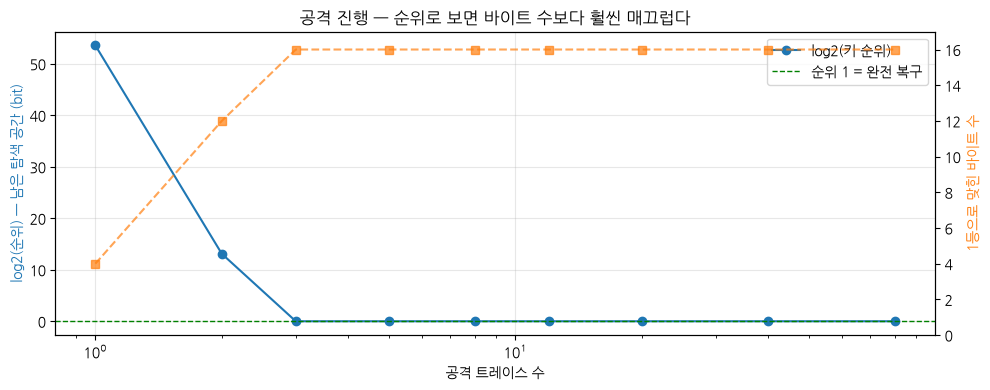

In [7]:
ms = [r[0] for r in rows]
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(ms, [r[2] for r in rows], "o-", color="C0", label="log2(키 순위)")
ax1.axhline(0, color="g", ls="--", lw=1, label="순위 1 = 완전 복구")
ax1.set_xscale("log"); ax1.set_xlabel("공격 트레이스 수")
ax1.set_ylabel("log2(순위) — 남은 탐색 공간 (bit)", color="C0")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(ms, [r[1] for r in rows], "s--", color="C1", alpha=0.7)
ax2.set_ylabel("1등으로 맞힌 바이트 수", color="C1"); ax2.set_ylim(0, 17)

ax1.legend(loc="upper right")
plt.title("공격 진행 — 순위로 보면 바이트 수보다 훨씬 매끄럽다")
fig.tight_layout(); plt.show()

`128 bit` 에서 시작해 `0 bit`(순위 1)로 내려간다. 바이트 단위 정오는 계단처럼 튀지만
순위는 연속적으로 줄어들어, **아직 성공하지 못한 공격의 진척도**까지 보여준다.
이것이 키랭크 추정을 쓰는 이유다.

---
## 4. `nbins` 와 정확도

빈 수가 적으면 빠르지만 상·하한 구간이 넓어진다.

In [8]:
lp = key_logprob_all(3); c = to_costs(lp)
print("nbins    순위          하한~상한 폭(log2)   소요")
for nb_ in (128, 512, 2048, 8192):
    t0 = time.time()
    a, b, d = rank_nbin(c, TRUE_KEY, nbins=nb_)
    print("%6d   %.4g   %14.3f   %.2f 초"
          % (nb_, b, np.log2(max(d, 1)) - np.log2(max(a, 1)), time.time() - t0))

nbins    순위          하한~상한 폭(log2)   소요
   128   1            0.000   0.01 초
   512   1            0.000   0.01 초
  2048   1            0.000   0.02 초
  8192   1            0.000   0.02 초


---
## 5. 요약

| 항목 | 내용 |
|------|------|
| 목적 | 바이트별 점수로 **128비트 키 전체의 순위**를 추정한다 |
| API | `rank_accuracy(costs, key, acc_bit)` · `rank_nbin(costs, key, nbins)` |
| `costs` | `(ns, nc)` `float64`, **작을수록 좋은 값**. 보통 음의 로그확률 |
| `key` | `(ns,)` 정답 부분키 |
| 반환 | `(하한, 추정, 상한)` — 근사이므로 구간으로 준다 |
| 쓰임 | 성공/실패 이분법 대신 **남은 탐색 공간**으로 공격을 평가한다 |

### 실패 시 점검

1. 비용의 부호가 뒤집히면 순위가 거꾸로 나온다. **작을수록 좋은 값**이어야 한다.
2. 확률이 0 인 후보가 있으면 `-log 0 = inf` 가 된다. `np.maximum(p, 1e-300)` 으로 막는다.
3. 상·하한 폭이 너무 넓다 → `nbins` 를 키우거나 `acc_bit` 를 줄인다.

이것으로 `[extra] SCALib` 예제를 마친다. 전체 지도는 `README.md` 참조.